=== Model Performance ===
      district        category     mae     r2       trend
0      Central  property_crime  368.25  0.003  Decreasing
1      Central      cybercrime   43.75  0.953  Increasing
2      Central   violent_crime    1.00  0.954  Increasing
3      Central    women_safety   13.30  0.956  Increasing
4         East  property_crime  265.50  0.003  Decreasing
5         East      cybercrime  166.80  0.911  Increasing
6         East   violent_crime    1.30  0.847  Increasing
7         East    women_safety    9.55  0.957  Increasing
8        North  property_crime  286.25  0.003  Decreasing
9        North      cybercrime  297.80  0.921  Increasing
10       North   violent_crime    1.20  0.889  Increasing
11       North    women_safety   10.95  0.952  Increasing
12       South  property_crime  348.00  0.003  Decreasing
13       South      cybercrime   99.80  0.950  Increasing
14       South   violent_crime    1.00  0.941  Increasing
15       South    women_safety   12.25  0.959 

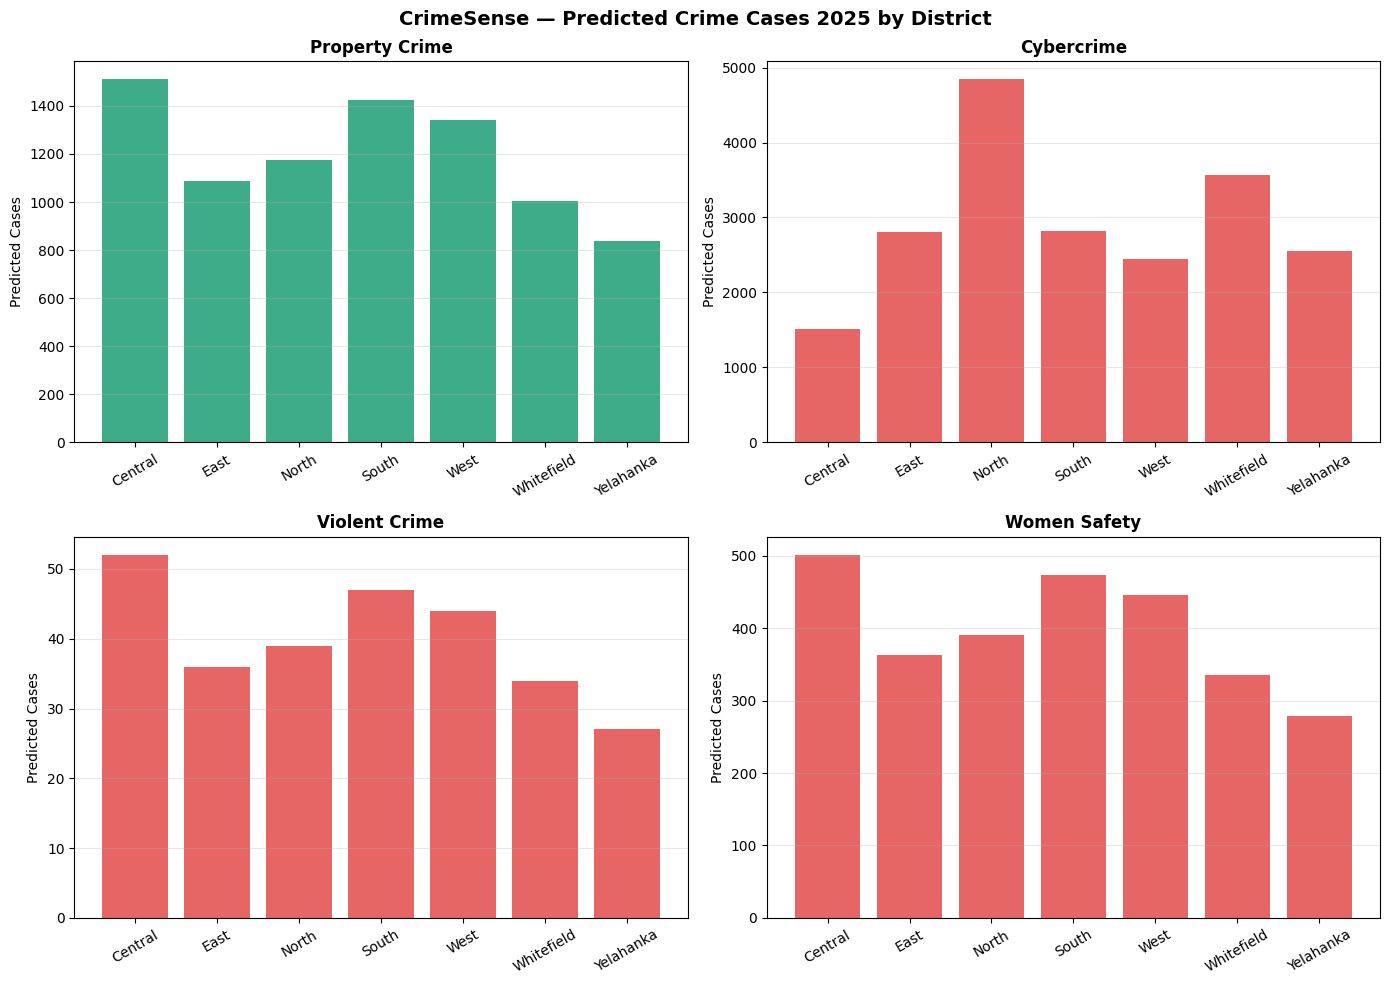

Saved: prediction_2025.png


In [2]:
# FILE: prediction.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('crimesense_clean.csv')

# ── Per district per category prediction ─────────────────────
results = []
predictions_2025 = []

categories = df['crime_category'].unique()
districts  = df['district'].unique()

for district in districts:
    for category in categories:

        subset = df[
            (df['district'] == district) &
            (df['crime_category'] == category)
        ].groupby('year')['cases'].sum().reset_index()

        if len(subset) < 3:
            continue

        X = subset['year'].values.reshape(-1, 1)
        y = subset['cases'].values

        model = LinearRegression()
        model.fit(X, y)

        y_pred = model.predict(X)
        mae    = mean_absolute_error(y, y_pred)
        r2     = r2_score(y, y_pred)

        pred_2025 = int(model.predict([[2025]])[0])
        pred_2025 = max(0, pred_2025)  # no negative cases

        results.append({
            'district': district, 'category': category,
            'mae': round(mae, 2), 'r2': round(r2, 3),
            'trend': 'Increasing' if model.coef_[0] > 0 else 'Decreasing'
        })

        predictions_2025.append({
            'district': district, 'category': category,
            'predicted_2025': pred_2025,
            'trend': 'Increasing' if model.coef_[0] > 0 else 'Decreasing'
        })

results_df = pd.DataFrame(results)
pred_df    = pd.DataFrame(predictions_2025)

print("=== Model Performance ===")
print(results_df.to_string())
print("\n=== 2025 Predictions ===")
print(pred_df.sort_values('predicted_2025', ascending=False).to_string())

# ── Save predictions ──────────────────────────────────────────
pred_df.to_csv('predictions_2025.csv', index=False)

# ── Plot: Predicted 2025 cases by district ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CrimeSense — Predicted Crime Cases 2025 by District', fontsize=14, fontweight='bold')

for ax, cat in zip(axes.flatten(), categories):
    subset = pred_df[pred_df['category'] == cat]
    colors = ['#E24B4A' if t == 'Increasing' else '#1D9E75' for t in subset['trend']]
    ax.bar(subset['district'], subset['predicted_2025'], color=colors, alpha=0.85)
    ax.set_title(cat.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Predicted Cases')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: prediction_2025.png")